In [45]:
import zarr
import re
import os
import gc
import time

import numpy as np
import scanpy as sc
import seaborn as sns
import pandas as pd

In [22]:
def sanitize_key(key):
    return re.sub(r'[^\w]', '_', str(key)).strip('_')

In [2]:
adata = sc.read_h5ad('/lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/kang/kang_2018.h5ad')
adata

AnnData object with n_obs × n_vars = 24673 × 15706
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters'
    var: 'name'
    obsm: 'X_pca', 'X_umap'

In [66]:
adata.X[100:110].toarray()

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [6]:
adata.obs

,nCount_RNA,nFeature_RNA,tsne1,tsne2,label,cluster,cell_type,replicate,nCount_SCT,nFeature_SCT,integrated_snn_res.0.4,seurat_clusters
index,,,,,,,,,,,,
AAACATACATTTCC-1,3017.0,877,-27.640373,14.966629,ctrl,9,CD14+ Monocytes,patient_1016,1704.0,711,1,1
AAACATACCAGAAA-1,2481.0,713,-27.493646,28.924885,ctrl,9,CD14+ Monocytes,patient_1256,1614.0,662,1,1
AAACATACCATGCA-1,703.0,337,-10.468194,-5.984389,ctrl,3,CD4 T cells,patient_1488,908.0,337,6,6
AAACATACCTCGCT-1,3420.0,850,-24.367997,20.429285,ctrl,9,CD14+ Monocytes,patient_1256,1738.0,653,1,1
AAACATACCTGGTA-1,3158.0,1111,27.952170,24.159738,ctrl,4,Dendritic cells,patient_1039,1857.0,928,12,12
...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGCATGCCTGAA-2,1033.0,468,18.268321,1.058202,stim,6,CD4 T cells,patient_1244,1128.0,468,2,2
TTTGCATGCCTGTC-2,2116.0,819,-11.563067,2.574095,stim,4,B cells,patient_1256,1669.0,799,3,3
TTTGCATGCTAAGC-2,1522.0,523,25.142392,6.603815,stim,6,CD4 T cells,patient_107,1422.0,523,0,0


In [60]:
adata.obs.replicate.value_counts()

replicate
patient_1015    5090
patient_1488    4580
patient_1256    4134
patient_1016    3358
patient_1244    3343
patient_101     2024
patient_1039    1102
patient_107     1042
Name: count, dtype: int64

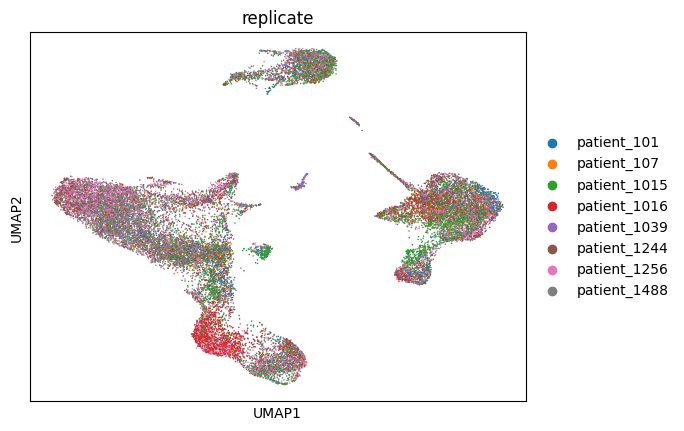

In [8]:
sc.pl.umap(adata, color="replicate")

In [24]:
adata2 = sc.read_h5ad('/lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/human_lungs/vieira19_concat.h5ad')
adata2.obs.loc[:, 'combination_key'] = adata2.obs.apply(
    lambda row: f"{sanitize_key(row['CellType'])}-"
                f"{sanitize_key(row['Donor'])}-"
                f"{sanitize_key(row['Location'])}",
    axis=1
)
adata2

AnnData object with n_obs × n_vars = 36931 × 33694
    obs: 'Sample', 'Donor', 'Source', 'Location', 'CellType', 'BroadCellType', 'combination_key'
    obsm: 'X_umap_hm'

In [69]:
adata2.X[100:110].toarray()

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 1.5451399, 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 1.4082069, 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ]], dtype=float32)

In [25]:
adata2.obs.combination_key.value_counts()

combination_key
Goblet_1-4-Nasal                                   2520
Ciliated_1-5-Bronchi                               2305
Luminal_Macrophages-302C-Alveoli_and_parenchyma    1973
Luminal_Macrophages-296C-Alveoli_and_parenchyma    1875
Basal_2-4-Bronchi                                  1639
                                                   ... 
B_cells-2-Bronchi                                     1
Ciliated_2-290B-Alveoli_and_parenchyma                1
Type_1_alveolar-292B-Alveoli_and_parenchyma           1
Smooth_muscle-290B-Alveoli_and_parenchyma             1
Mesothelium-290B-Alveoli_and_parenchyma               1
Name: count, Length: 192, dtype: int64

In [27]:
adata2.obsm["X_umap"] = adata2.obsm["X_umap_hm"]

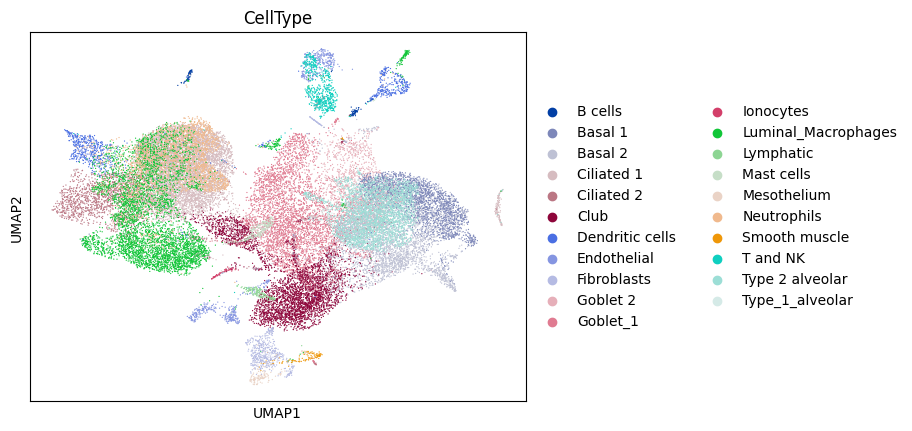

In [32]:
sc.pl.umap(adata2, color='CellType')

In [33]:
adata3 = sc.read_h5ad('/lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/replogle/replogle.h5ad')
adata3

AnnData object with n_obs × n_vars = 643413 × 6642
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'cell_line'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg'
    obsm: 'X_hvg'

In [71]:
adata3.X[100:110]

array([[0.        , 0.51066566, 1.609118  , ..., 2.707677  , 0.51066566,
        3.6459303 ],
       [0.6301877 , 1.2903035 , 0.6301877 , ..., 3.3399196 , 1.6845112 ,
        4.253612  ],
       [0.        , 1.158776  , 0.7386059 , ..., 2.9745734 , 0.        ,
        4.0576253 ],
       ...,
       [0.        , 0.        , 0.        , ..., 2.775923  , 0.        ,
        4.578231  ],
       [0.        , 0.9936644 , 0.61548674, ..., 2.9371333 , 1.4821109 ,
        4.03045   ],
       [0.        , 1.5439905 , 0.        , ..., 3.1398087 , 1.0443746 ,
        4.762363  ]], dtype=float32)

In [34]:
adata3.obs

,gem_group,gene,gene_id,transcript,gene_transcript,sgID_AB,mitopercent,UMI_count,z_gemgroup_UMI,cell_line
cell_barcode,,,,,,,,,,
AAACCCAAGAATAGTC-3,3,KIAA1143,ENSG00000163807,P1P2,4360_KIAA1143_P1P2_ENSG00000163807,KIAA1143_+_44803075.23-P1P2|KIAA1143_+_4480308...,0.114029,11234.0,-0.611091,hepg2
AAACCCAAGAGGTATT-55,55,SEPHS2,ENSG00000179918,P1P2,7779_SEPHS2_P1P2_ENSG00000179918,SEPHS2_-_30457178.23-P1P2|SEPHS2_+_30457164.23...,0.165242,45146.0,0.208833,hepg2
AAACCCAAGAGTGACC-39,39,POLR2H,ENSG00000163882,P1P2,6549_POLR2H_P1P2_ENSG00000163882,POLR2H_+_184081227.23-P1P2|POLR2H_-_184081237....,0.162209,20190.0,-0.025114,hepg2
AAACCCAAGATGGCAC-43,43,TFAM,ENSG00000108064,P1P2,8832_TFAM_P1P2_ENSG00000108064,TFAM_+_60145205.23-P1P2|TFAM_-_60145223.23-P1P2,0.071596,23912.0,2.079665,hepg2
AAACCCAAGCAACAAT-16,16,TMEM214,ENSG00000119777,P1P2,9042_TMEM214_P1P2_ENSG00000119777,TMEM214_-_27255873.23-P1P2|TMEM214_-_27255853....,0.109515,8282.0,-0.214576,hepg2
...,...,...,...,...,...,...,...,...,...,...
TTTGTTGTCTGATGGT-14,14,SLC1A5,ENSG00000105281,P1,7976_SLC1A5_P1_ENSG00000105281,SLC1A5_+_47291839.23-P1|SLC1A5_+_47291829.23-P1,0.062634,15423.0,0.347911,rpe1
TTTGTTGTCTGCACCT-44,44,MAX,ENSG00000125952,P1P2,4871_MAX_P1P2_ENSG00000125952,MAX_+_65569008.23-P1P2|MAX_-_65568906.23-P1P2,0.079629,22228.0,0.767826,rpe1
TTTGTTGTCTGGGCAC-32,32,ATP6V0C,ENSG00000185883,P1P2,675_ATP6V0C_P1P2_ENSG00000185883,ATP6V0C_+_2564168.23-P1P2|ATP6V0C_-_2563995.23...,0.049527,12377.0,-0.004215,rpe1


In [38]:
adata3.obs.cell_line.value_counts()

cell_line
k562      188590
jurkat    184470
rpe1      173737
hepg2      96616
Name: count, dtype: int64

In [43]:
adata3.obs.gene.value_counts()

gene
non-targeting    39165
TFAM              7145
SLC1A5            4284
GFM1              3969
MRPL36            3254
                 ...  
MST1                31
OGT                 31
DDX3X               30
DDX42               30
CDC27               30
Name: count, Length: 2024, dtype: int64

In [59]:
tmp = adata3.obs.gene.value_counts()
len(tmp[tmp>=100])

1743

In [35]:
adata4 = sc.read_h5ad('/lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/k562_essential/K562_essential_normalized_singlecell_01.h5ad')
adata5 = sc.read_h5ad('/lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/rpe1_essential/rpe1_normalized_singlecell_01.h5ad')

In [73]:
adata5.X[100:110]

array([[  0.,   0.,   0., ...,   3.,   2.,   1.],
       [  0.,   0.,   0., ...,  19.,   1., 111.],
       [  2.,   0.,   1., ...,  33.,   6.,  83.],
       ...,
       [  0.,   0.,   4., ...,  43.,   2., 147.],
       [  0.,   0.,   0., ...,  18.,   1.,  24.],
       [  1.,   0.,   1., ...,  24.,   6.,  62.]], dtype=float32)

In [37]:
len(set(adata4.var.index.tolist()).intersection(adata5.var.index.tolist()))

7226

In [77]:
mean_umi = np.asarray(adata4.X.mean(axis=0)).ravel()
print("min mean UMI/cell:", mean_umi.min())
print("genes with mean < 0.1:", (mean_umi < 0.1).sum())

min mean UMI/cell: 0.10555278
genes with mean < 0.1: 0


In [78]:
adata6 = sc.read_h5ad('/lustre/groups/ml01/workspace/xiaotong.fu/data/reconstruction/luca_counts/luca.h5ad')
adata6

AnnData object with n_obs × n_vars = 892296 × 5983
    obs: 'sample', 'uicc_stage', 'ever_smoker', 'age', 'donor_id', 'origin', 'dataset', 'ann_fine', 'cell_type_predicted', 'doublet_status', 'leiden', 'n_genes_by_counts', 'total_counts', 'total_counts_mito', 'pct_counts_mito', 'ann_coarse', 'cell_type_tumor', 'tumor_stage', 'TP53_mutation', 'ALK_mutation', 'BRAF_mutation', 'ERBB2_mutation', 'KRAS_mutation', 'ROS_mutation', 'origin_fine', 'study', 'platform', 'cell_type_major', 'suspension_type', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'tissue_type', 'EGFR_mutation', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'is_highly_variable', 'mito', 'n_cells_by_counts', 'mean_coun